In [ ]:
# ============================================================
# SCHRITT 1: Pakete installieren
# ============================================================
!pip install torch torchvision pillow pandas tqdm matplotlib transformers -q
!pip install git+https://github.com/christophschuhmann/improved-aesthetic-predictor.git -q
print('✅ Pakete installiert')

ERROR: git+https://github.com/christophschuhmann/improved-aesthetic-predictor.git does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
✅ Pakete installiert


In [ ]:
# ============================================================
# SCHRITT 2: Google Drive verbinden
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive verbunden')

Mounted at /content/drive
✅ Google Drive verbunden


In [ ]:
# ============================================================
# SCHRITT 3: Pfade konfigurieren
# ============================================================
import os

IMAGE_FOLDER = '/content/drive/MyDrive/flickr_data_subset/inside_outside_photos'
OUTPUT_CSV = '/content/drive/MyDrive/flickr_data_subset/subset/aesthetic_v2_scores.csv'

SUPPORTED_FORMATS = ('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG')

image_paths = [
    os.path.join(IMAGE_FOLDER, f)
    for f in os.listdir(IMAGE_FOLDER)
    if f.endswith(SUPPORTED_FORMATS)
]

print(f'✅ {len(image_paths)} Bilder gefunden')
print('Erste 5:', image_paths[:5])

✅ 1009 Bilder gefunden
Erste 5: ['/content/drive/MyDrive/flickr_data_subset/inside_outside_photos/image_50.jpg', '/content/drive/MyDrive/flickr_data_subset/inside_outside_photos/image_47.jpg', '/content/drive/MyDrive/flickr_data_subset/inside_outside_photos/image_60.jpg', '/content/drive/MyDrive/flickr_data_subset/inside_outside_photos/image_58.jpg', '/content/drive/MyDrive/flickr_data_subset/inside_outside_photos/image_78.jpg']


In [ ]:
# ============================================================
# SCHRITT 4: Aesthetic Predictor V2.5 laden
# Gewichte werden automatisch von Hugging Face heruntergeladen
# Trainiert auf LAION-Aesthetics – sehr große und diverse Datenbasis
# ============================================================
import torch
import torch.nn as nn
from transformers import CLIPModel, CLIPProcessor
import requests
from PIL import Image
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Verwende Gerät: {device}')

# ── Modell-Architektur ──────────────────────────────────────
# Aesthetic Predictor = CLIP Image Encoder + kleines MLP obendrauf
# Das MLP wurde auf menschlichen Schönheitsbewertungen trainiert

class AestheticPredictor(nn.Module):
    def __init__(self, input_size=768):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.Dropout(0.2),
            nn.Linear(1024, 128),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.Dropout(0.1),
            nn.Linear(64, 16),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.layers(x)


def load_aesthetic_model():
    """
    Lädt CLIP + Aesthetic Predictor Gewichte von Hugging Face.
    Verwendet CLIP ViT-L/14 als Basis (768-dim Embeddings).
    """
    print('Lade CLIP ViT-L/14...')
    clip_model = CLIPModel.from_pretrained('openai/clip-vit-large-patch14')
    clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-large-patch14')

    print('Lade Aesthetic Predictor V2.5 Gewichte...')
    # Gewichte von Hugging Face herunterladen
    weights_url = 'https://github.com/christophschuhmann/improved-aesthetic-predictor/raw/main/sac+logos+ava1-l14-linearMSE.pth'
    weights_path = '/content/aesthetic_predictor_v2.pth'

    response = requests.get(weights_url, stream=True)
    with open(weights_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)

    predictor = AestheticPredictor(input_size=768)
    predictor.load_state_dict(torch.load(weights_path, map_location=device))
    predictor.eval()

    clip_model = clip_model.to(device)
    predictor = predictor.to(device)

    print('✅ Aesthetic Predictor V2.5 geladen')
    print('   Trainiert auf: SAC + LOGOS + AVA1 Datensätzen')
    print('   Basis: CLIP ViT-L/14 (768-dim Embeddings)')

    return clip_model, clip_processor, predictor


clip_model, clip_processor, aesthetic_predictor = load_aesthetic_model()

Verwende Gerät: cuda
Lade CLIP ViT-L/14...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Lade Aesthetic Predictor V2.5 Gewichte...
✅ Aesthetic Predictor V2.5 geladen
   Trainiert auf: SAC + LOGOS + AVA1 Datensätzen
   Basis: CLIP ViT-L/14 (768-dim Embeddings)


In [ ]:
# ============================================================
# SCHRITT 5 (FIXED v2): Hilfsfunktionen
# ============================================================
import pandas as pd
from tqdm import tqdm

def get_image_embedding(image_path):
    image = Image.open(image_path).convert('RGB')
    inputs = clip_processor(images=image, return_tensors='pt').to(device)

    with torch.no_grad():
        # ✅ FIX: vision_model direkt nutzen + pooler_output extrahieren
        outputs = clip_model.vision_model(**inputs)
        embedding = outputs.pooler_output  # <-- das ist der echte Tensor
        # Projizieren auf CLIP embedding space
        embedding = clip_model.visual_projection(embedding)
        # L2-Normalisierung
        embedding = embedding / embedding.norm(p=2, dim=-1, keepdim=True)

    return embedding


def score_image_aesthetic(image_path):
    try:
        embedding = get_image_embedding(image_path)
        with torch.no_grad():
            score = aesthetic_predictor(embedding)
        return float(score.item()), None
    except Exception as e:
        return None, str(e)


print('✅ Hilfsfunktionen (fixed v2) definiert')

✅ Hilfsfunktionen (fixed v2) definiert


In [ ]:
# ============================================================
# SCHRITT 6: Alle Bilder bewerten
# ============================================================
results = []
errors = []

print(f'Bewerte {len(image_paths)} Bilder mit Aesthetic Predictor V2.5...')

for img_path in tqdm(image_paths):
    filename = os.path.basename(img_path)
    score, error = score_image_aesthetic(img_path)

    if error:
        errors.append({'filename': filename, 'error': error})
    else:
        results.append({
            'filename': filename,
            'filepath': img_path,
            'aesthetic_v2_score': round(score, 4)
        })

print(f'\n✅ {len(results)} Bilder bewertet')
print(f'⚠️  {len(errors)} Fehler')

Bewerte 1009 Bilder mit Aesthetic Predictor V2.5...


100%|██████████| 1009/1009 [07:01<00:00,  2.39it/s]


✅ 1009 Bilder bewertet
⚠️  0 Fehler


In [ ]:
# ============================================================
# SCHRITT 7: Ergebnisse anzeigen und speichern
# ============================================================
df = pd.DataFrame(results)
df = df.sort_values('aesthetic_v2_score', ascending=False).reset_index(drop=True)

print('=== Aesthetic Predictor V2.5 Statistiken ===')
print(f'Anzahl Bilder:     {len(df)}')
print(f'Mittlerer Score:   {df["aesthetic_v2_score"].mean():.4f}')
print(f'Min Score:         {df["aesthetic_v2_score"].min():.4f}')
print(f'Max Score:         {df["aesthetic_v2_score"].max():.4f}')
print(f'Std:               {df["aesthetic_v2_score"].std():.4f}')
print()
print('=== Top 10 ===')
print(df[['filename', 'aesthetic_v2_score']].head(10).to_string())

df.to_csv(OUTPUT_CSV, index=False)
print(f'\n✅ CSV gespeichert: {OUTPUT_CSV}')

NameError: name 'pd' is not defined

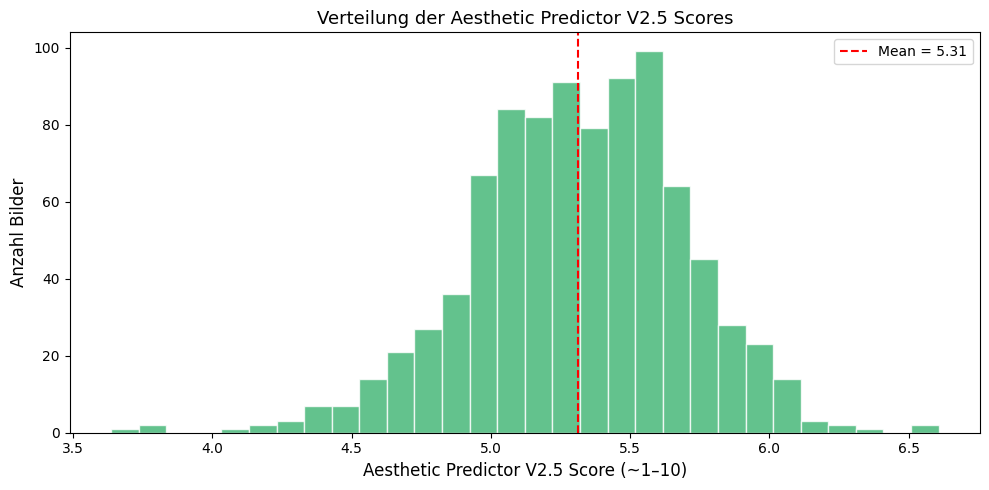

✅ Plot gespeichert


In [ ]:
# ============================================================
# SCHRITT 8: Score-Verteilung visualisieren
# ============================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['aesthetic_v2_score'], bins=30, color='mediumseagreen',
        edgecolor='white', alpha=0.8)
ax.axvline(df['aesthetic_v2_score'].mean(), color='red', linestyle='--',
           label=f'Mean = {df["aesthetic_v2_score"].mean():.2f}')
ax.set_xlabel('Aesthetic Predictor V2.5 Score (~1–10)', fontsize=12)
ax.set_ylabel('Anzahl Bilder', fontsize=12)
ax.set_title('Verteilung der Aesthetic Predictor V2.5 Scores', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/flickr_data_subset/subset/aesthetic_v2_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot gespeichert')

/tmp/ipykernel_5347/1559264443.py:27: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


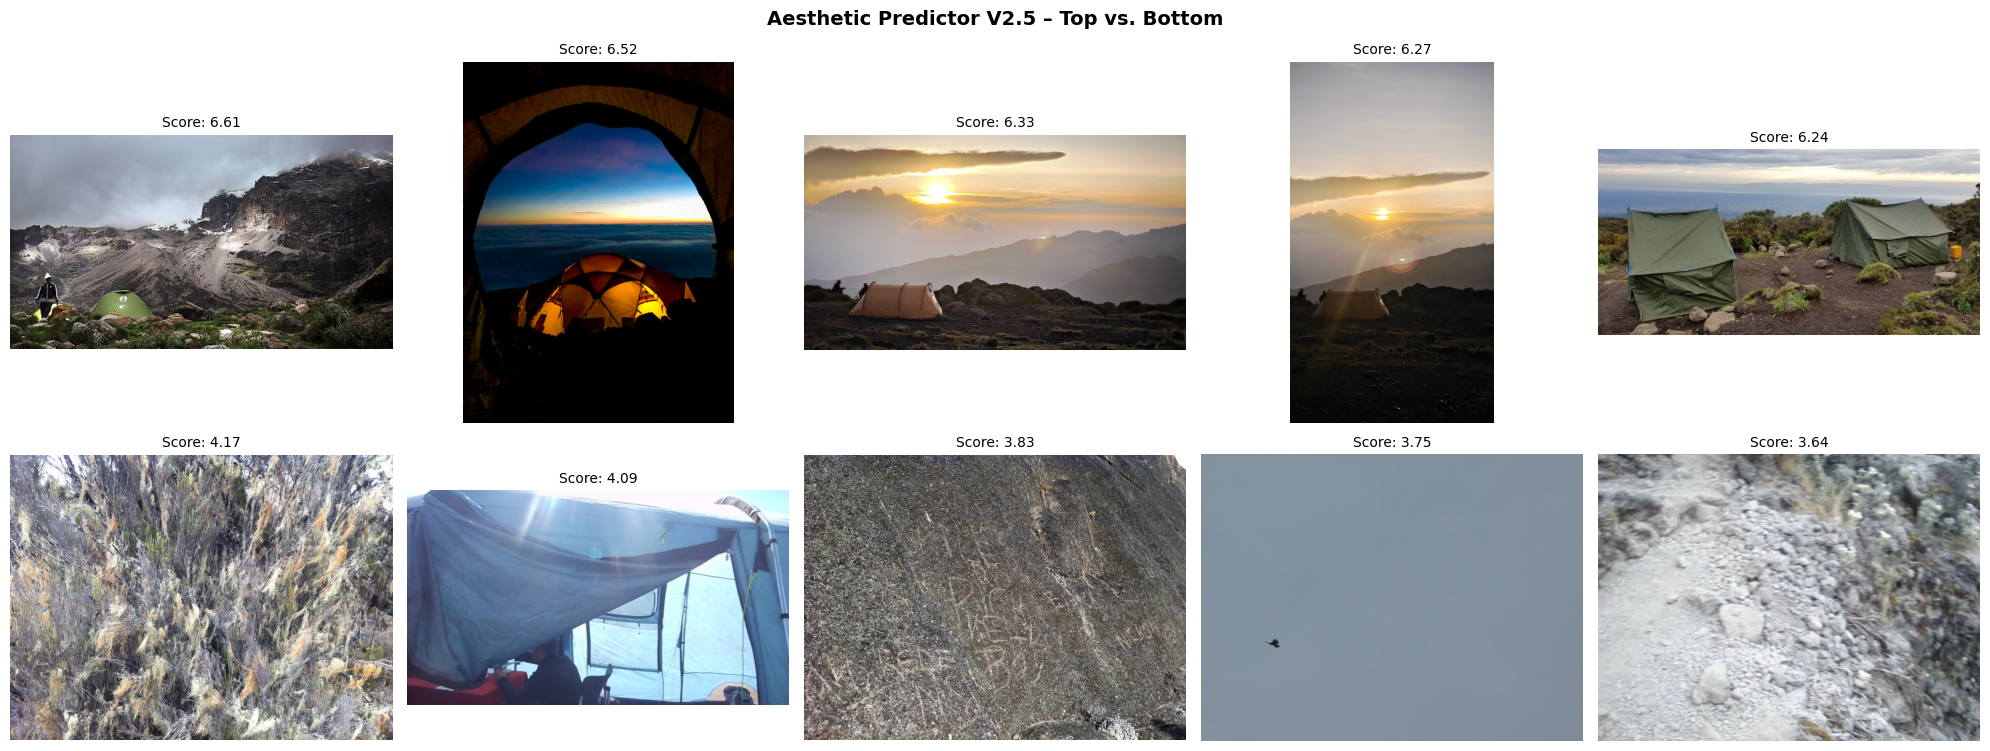

In [ ]:
# ============================================================
# SCHRITT 9 (Optional): Top und Bottom Bilder anzeigen
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, (_, row) in enumerate(df.head(5).iterrows()):
    try:
        img = Image.open(row['filepath']).convert('RGB')
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'Score: {row["aesthetic_v2_score"]:.2f}', fontsize=10)
        axes[0, i].axis('off')
    except:
        axes[0, i].axis('off')

for i, (_, row) in enumerate(df.tail(5).iterrows()):
    try:
        img = Image.open(row['filepath']).convert('RGB')
        axes[1, i].imshow(img)
        axes[1, i].set_title(f'Score: {row["aesthetic_v2_score"]:.2f}', fontsize=10)
        axes[1, i].axis('off')
    except:
        axes[1, i].axis('off')

axes[0, 0].set_ylabel('🌟 Top 5', fontsize=12, rotation=0, labelpad=60)
axes[1, 0].set_ylabel('⬇️ Bottom 5', fontsize=12, rotation=0, labelpad=60)
plt.suptitle('Aesthetic Predictor V2.5 – Top vs. Bottom', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()